In [4]:
nlp--- natural language processing

whenever u r dealing with text data that will be called as nlp 

SyntaxError: invalid syntax (4190835543.py, line 1)

In [1]:
#Importing all the neccessary libraries
%matplotlib inline
import sqlite3
import pandas as pd
import numpy as np
import nltk
import string
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfTransformer,TfidfVectorizer, CountVectorizer
import sklearn.metrics as metrics
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
from nltk.stem.porter import PorterStemmer
import string
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
#from gensim.models import Word2Vec, KeyedVectors
import pickle
import warnings
warnings.filterwarnings("ignore")
from sklearn import datasets, neighbors
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from collections import Counter
from matplotlib.colors import ListedColormap
#import scikitplot.metrics as sciplot
from sklearn.metrics import accuracy_score
import math
import nltk
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\chara\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
!pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   - -------------------------------------- 1.0/24.4 MB 7.1 MB/s eta 0:00:04
   --- ------------------------------------ 2.4/24.4 MB 5.7 MB/s eta 0:00:04
   --------- ------------------------------ 5.5/24.4 MB 8.5 MB/s eta 0:00:03
   -------------- ------------------------- 8.9/24.4 MB 10.5 MB/s eta 0:00:02
   ------------------------ --------------- 14.7/24.4 MB 14.1 MB/s eta 0:00:01
   ------------------------- -------------- 15.7/24.4 MB 12.5 MB/s eta 0:00:01
   ----------------------------- ---------- 17.8/24.4 MB 12.1 MB/s eta 0:00:01
   --------------------------------- ------ 20.7/24.4 MB 12.2 MB/s eta 0:00:01
   ----------------------------------- ---- 21.8/24.4 MB 11.6 MB/s eta 0:00:01
   -------------------------------------- - 23.3/24.4 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------- 24.4/24.4 MB 10.8 MB/s  0:00:02



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
sentiment analysis:finding the text data  whether the text data is positive or negative or neutral is called as sentiment analysis

the benifit of sentiment analysis is that it can help us to understand the customer feedback and also it can help us to understand the market trend and also it can help us to understand the customer behavior and also it can help us to understand the customer preference and also it can help us to understand the customer satisfaction and also it can help us to understand the customer loyalty and also it can help us to understand the customer retention and also it can help us to understand the customer acquisition and also it can help us to understand the customer engagement and also it can help us to understand the customer experience and also it can help us to understand the customer journey and also it can help us to understand the customer feedback and also it can help us to understand the customer sentiment and also it can help us to understand the customer opinion and also it can help us to understand the customer review and also it can help us to understand the customer rating and also it can help us to understand the customer feedback and also it can help us to understand the customer sentiment analysis and also it can help us to understand the customer opinion mining and also it can help us to understand the customer review analysis and also it can help us to understand the customer rating analysis

reviews,comments,feedback,opinion,customer review,customer feedback,customer opinion,customer sentiment,customer rating,customer review analysis,customer feedback analysis,customer opinion mining,customer sentiment analysis,customer rating analysis


In [2]:
filtered_data = pd.read_csv(r'C:\Users\chara\Downloads\Reviews.csv')

In [3]:
filtered_data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
filtered_data.shape

(568454, 10)

In [5]:
filtered_data = filtered_data.sample(frac=0.1, random_state=1)

In [ ]:

what if don't have scores in my dataset?
based on the text data: whether the text data is positive or negative or neutral
keywords from the text data :
positive words : good, excellent, amazing, fantastic, great, awesome, wonderful, perfect, nice, love
negative words : bad, terrible, awful, horrible, worst, poor, disappointing, hate, disgusting, nasty
neutral words : average, okay, fine, decent, mediocre, fair, passable, tolerable, acceptable, satisfactory


In [6]:
#Give reviews with Score > 3 a 'Positive' tag, and reviews with a score < 3 a 'Negative' tag.
filtered_data['SentimentPolarity'] = filtered_data['Score'].apply(lambda x : 'Positive' if x > 3 else 'Negative' if x < 3 else 'Neutral')

In [7]:
filtered_data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,SentimentPolarity
288312,288313,B000ENUC3S,AN66F3Q4QNU43,Donna Speaker,0,0,5,1340496000,Cherry Pie Larabar,I love the Cherry Pie Lara bar. Best and tast...,Positive
431726,431727,B002TMV3CG,A3G007LQX6KGOD,SevereWX,0,0,5,1287878400,Melitta Coffee,Melitta Cafe COllection Blanc et Noir coffee h...,Positive
110311,110312,B004867T24,A11LNY2OLQSUSV,M. Castillo,0,0,5,1331769600,great treat,my girls absolutely loved this tuna. they were...,Positive
91855,91856,B004U7KPY0,A1QCYVHWO5934U,"PistolaMia ""PistolaMia""",0,0,5,1332806400,Daily Calming,The vendor is fast and dependable. The tea is ...,Positive
338855,338856,B000FD78R0,A30U2QQN2FFHE9,J. Amicucci,2,3,5,1271376000,Best Canned Artichokes Out There!,UPDATE - 8/9/2010<br />A lot can happen in jus...,Positive


In [8]:
filtered_data['SentimentPolarity'].value_counts()

SentimentPolarity
Positive    44391
Negative     8163
Neutral      4291
Name: count, dtype: int64

In [9]:

#score greater than 3 as postive  and equal to 3 as neutral and less than 3 as negative
#filtered_data['SentimentPolarity'] = filtered_data['Score'].apply(lambda x : 'Positive' if x > 3 else (if x < 3 else 'Neutral'))
#score greater than 3 as postive  and equal to 3 as neutral and less than 3 as negative and give more priority to negative words
#filtered_data['SentimentPolarity'] = filtered_data['Score'].apply(lambda x : 'Positive' if x > 3 else ('Negative' if x < 3 else 'Neutral'))
filtered_data['Class_Labels'] = filtered_data['SentimentPolarity'].apply(lambda x : 1 if x == 'Positive' else 0 if x == 'Negative' else 2)

In [10]:
filtered_data.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,SentimentPolarity,Class_Labels
288312,288313,B000ENUC3S,AN66F3Q4QNU43,Donna Speaker,0,0,5,1340496000,Cherry Pie Larabar,I love the Cherry Pie Lara bar. Best and tast...,Positive,1
431726,431727,B002TMV3CG,A3G007LQX6KGOD,SevereWX,0,0,5,1287878400,Melitta Coffee,Melitta Cafe COllection Blanc et Noir coffee h...,Positive,1
110311,110312,B004867T24,A11LNY2OLQSUSV,M. Castillo,0,0,5,1331769600,great treat,my girls absolutely loved this tuna. they were...,Positive,1
91855,91856,B004U7KPY0,A1QCYVHWO5934U,"PistolaMia ""PistolaMia""",0,0,5,1332806400,Daily Calming,The vendor is fast and dependable. The tea is ...,Positive,1
338855,338856,B000FD78R0,A30U2QQN2FFHE9,J. Amicucci,2,3,5,1271376000,Best Canned Artichokes Out There!,UPDATE - 8/9/2010<br />A lot can happen in jus...,Positive,1
243608,243609,B0059X9A6I,AUDQL0QLM3Y58,chuck harris,0,0,5,1337731200,WOW!,I have pretty much tried them all. The dark ch...,Positive,1
152343,152344,B000LKZD4W,A1QGQ6BDB5PR2X,Carolyn McCray,1,1,5,1347667200,Love this product,"Just be forewarned it is a bit ""moist."" Have ...",Positive,1
336202,336203,B000BRR8VQ,A1GE2Q2WR6G9G,tech geek,0,0,5,1333497600,These are amazing treats and a great value,Both of my mixed terrier dogs prefer this trea...,Positive,1
488611,488612,B004JQVAVO,A1OH8NY6IBSDJ7,J. P. Delese Jr.,1,2,1,1307059200,can't drink it,Made this coffee with a percolator maybe that ...,Negative,0
103618,103619,B0083L5F8K,A2KXPOM62YFOBT,C. Daughtridge,0,0,5,1340582400,everything I needed,This was just the basic ingredients that i cou...,Positive,1


In [11]:
print("The number of positive and negative reviews before the removal of duplicate data.")
print(filtered_data["SentimentPolarity"].value_counts())

The number of positive and negative reviews before the removal of duplicate data.
SentimentPolarity
Positive    44391
Negative     8163
Neutral      4291
Name: count, dtype: int64


In [12]:
#Removing duplicate entries based on past knowledge.
filtered_duplicates=filtered_data.drop_duplicates(subset={"UserId","ProfileName","Time","Text"}, keep='first', inplace=True)

In [13]:
print("The number of positive and negative reviews after the removal of duplicate data.")
print(filtered_data["SentimentPolarity"].value_counts())

The number of positive and negative reviews after the removal of duplicate data.
SentimentPolarity
Positive    40741
Negative     7518
Neutral      3932
Name: count, dtype: int64


In [14]:
#Removing the entries where HelpfulnessNumerator > HelpfulnessDenominator.
final_data=filtered_data[filtered_data.HelpfulnessNumerator <= filtered_data.HelpfulnessDenominator]

In [15]:
final_data["SentimentPolarity"].value_counts()

SentimentPolarity
Positive    40741
Negative     7518
Neutral      3932
Name: count, dtype: int64

In [16]:
1. I am creating a copy of the final_data dataset called 'sampled_dataset' by dropping the unwanted columns that we don't need for this problem.
2. Sorting the data according to time, such that the oldest reviews are displayed at the top and the latest reviews are displayed at the bottom.
3. Displaying information about the number of postive and negative reviews in the sampled dataset, using a Histogram.

SyntaxError: unterminated string literal (detected at line 1) (3262054393.py, line 1)

In [17]:
#Dropping unwanted columns for now.
sampled_dataset=final_data.drop(labels=['Id','ProductId', 'UserId', 'Score', 'ProfileName','HelpfulnessNumerator', 'HelpfulnessDenominator','Summary'], axis=1)
print("The shape of the sampled dataset after dropping unwanted columns : ", sampled_dataset.shape)
sampled_dataset.head(10)

The shape of the sampled dataset after dropping unwanted columns :  (52191, 4)


,Time,Text,SentimentPolarity,Class_Labels
288312,1340496000,I love the Cherry Pie Lara bar. Best and tast...,Positive,1
431726,1287878400,Melitta Cafe COllection Blanc et Noir coffee h...,Positive,1
110311,1331769600,my girls absolutely loved this tuna. they were...,Positive,1
91855,1332806400,The vendor is fast and dependable. The tea is ...,Positive,1
338855,1271376000,UPDATE - 8/9/2010<br />A lot can happen in jus...,Positive,1
243608,1337731200,I have pretty much tried them all. The dark ch...,Positive,1
152343,1347667200,"Just be forewarned it is a bit ""moist."" Have ...",Positive,1
336202,1333497600,Both of my mixed terrier dogs prefer this trea...,Positive,1
488611,1307059200,Made this coffee with a percolator maybe that ...,Negative,0
103618,1340582400,This was just the basic ingredients that i cou...,Positive,1


In [18]:
#Sorting data according to Time in ascending order => Time Based Splitting Step 1.
sampled_dataset=sampled_dataset.sort_values('Time', axis=0, ascending=False, inplace=False, kind='quicksort', na_position='last')

In [19]:
sampled_dataset = sampled_dataset.reset_index()

In [20]:
sampled_dataset.head()

,index,Time,Text,SentimentPolarity,Class_Labels
0,480031,1351209600,This past summer I started experimenting with ...,Positive,1
1,322327,1351209600,At last a sweetener with hardly any of that na...,Positive,1
2,180007,1351209600,"Every month, we give our three dogs (two Aussi...",Positive,1
3,381894,1351209600,My daughter buys this brand locally.... The on...,Negative,0
4,10627,1351209600,I love this product and order it frequently. ...,Neutral,2


In [21]:
sampled_dataset=sampled_dataset.drop(labels=['index'], axis=1)

In [22]:
sampled_dataset.head()

,Time,Text,SentimentPolarity,Class_Labels
0,1351209600,This past summer I started experimenting with ...,Positive,1
1,1351209600,At last a sweetener with hardly any of that na...,Positive,1
2,1351209600,"Every month, we give our three dogs (two Aussi...",Positive,1
3,1351209600,My daughter buys this brand locally.... The on...,Negative,0
4,1351209600,I love this product and order it frequently. ...,Neutral,2


<Axes: title={'center': 'Distribution Of Positive and Negative reviews after De-Duplication.'}, xlabel='SentimentPolarity'>

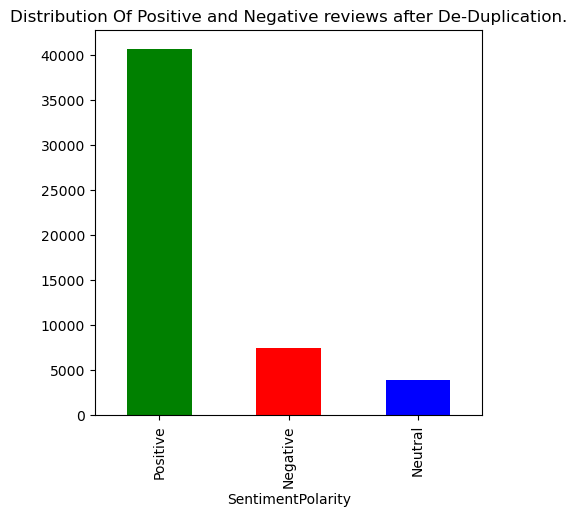

In [23]:
#Display distribution of Postive and Negative reviews in a bar graph
sampled_dataset["SentimentPolarity"].value_counts().plot(kind='bar',color=['green','red','blue'],title='Distribution Of Positive and Negative reviews after De-Duplication.',figsize=(5,5))

In [ ]:
#### In this code block : text extraction and cleaning

1. We define two functions which will remove the HTML tags and punctuations from each review.
2. At the end of this code block, each review will contain texts which will only contain alphabetical strings. 
3. We will apply techniques such as stemming and stopwords removal.
3. We will create two columns in the sampled dataset - 'CleanedText' and 'RemovedHTML'.
4. 'CleanedText' column will basically contain the data corpus after stemming the each reviews and removing stopwords from each review. We will use this for our Bag of Word model.
5. 'RemovedHTML' column will contain the data corpus from which only the HTML tags and punctuations are removed. We will use this column for our TF-IDF model, Average Word2Vec model and TF-IDF weighted average Word2Vec model.
6. Store the final table in a dataset called 'sampled_dataset' for future use.

SyntaxError: invalid syntax (1729699825.py, line 3)

In [24]:
import re


review = "i am satisfied with the product , and the service is good... @  ! 7 % $ and the delivery is on time <br /> <br /> overall i am happy with the product.product"


'''Data Cleaning Stage. Clean each review from the sampled Amazon Dataset.'''
#Data Cleaning Stage. Clean each review from the sampled Amazon Dataset

#Function to clean html tags from a sentence
def removeHtml(sentence): 
    pattern = re.compile('<.*?>')## re--regex pattern to remove html tags
    cleaned_text = re.sub(pattern,' ',sentence)
    return cleaned_text
cleaned_review=removeHtml(review)
print("The review after removing html tags : ",cleaned_review)


The review after removing html tags :  i am satisfied with the product , and the service is good... @  ! 7 % $ and the delivery is on time     overall i am happy with the product.product


In [25]:
#Function to keep only words containing letters A-Z and a-z. This will remove all punctuations, special characters etc.
def removePunctuations(sentence):
    cleaned_text  = re.sub('[^a-zA-Z]',' ',sentence)
    return cleaned_text

In [26]:
cleaned_review_only_text = removePunctuations(cleaned_review)
print("The review after removing  Punctuations : ",cleaned_review_only_text)

The review after removing  Punctuations :  i am satisfied with the product   and the service is good               and the delivery is on time     overall i am happy with the product product


In [27]:
# ineed to strip the text data and convert it into lower case
#Function to convert the entire sentence to lower case and strip the extra spaces.  
def stripLower(sentence):                     
    cleaned_text = sentence.lower().strip()
    cleaned_text = re.sub(' +', ' ', cleaned_text)
    return cleaned_text

In [28]:
final_cleaned_review = stripLower(cleaned_review_only_text)
print("The review after converting to lower case and stripping extra spaces : ",final_cleaned_review)

The review after converting to lower case and stripping extra spaces :  i am satisfied with the product and the service is good and the delivery is on time overall i am happy with the product product


In [29]:
final_cleaned_review

'i am satisfied with the product and the service is good and the delivery is on time overall i am happy with the product product'

In [30]:
def take_only_distinct_words(sentence):
    word_tokens = sentence.split()
    #print("The word tokens are : ", word_tokens)
    seen = set()
    cleaned_text = []
    for word in word_tokens:
        if word not in seen:
            cleaned_text.append(word)
            seen.add(word)
    #print("The distinct words are : ", cleaned_text)
    cleaned_text = ' '.join(cleaned_text)
    return cleaned_text

cleaned_review_distinct_words = take_only_distinct_words(final_cleaned_review)
print("The review after taking only distinct words : ", cleaned_review_distinct_words)

The review after taking only distinct words :  i am satisfied with the product and service is good delivery on time overall happy


In [31]:
## preprocessing steps : stopwords removal and stemming,lemmatization
import nltk   #spacy
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\chara\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [32]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [33]:
# my next step is to remove stop words from the text data
#Function to remove stop words from a sentence  
nltk.download('stopwords')
def removeStopWords(sentence):
    stop_words = set(stopwords.words('english'))
    # need to take all negative words from the stop words in list after that we will remove those words from the stop words
    #print("The stop words are : ", stop_words)
    negative_words = ["not", "no", "nor", "never", "don't", "didn't", "doesn't", "isn't", "wasn't", "shouldn't", "wouldn't", "couldn't", "won't", "haven't", "hasn't", "hadn't", "mightn't", "mustn't", "shan't"]
    #print("The negative words are : ", negative_words)
    stop_words = stop_words - set(negative_words)
    word_tokens = sentence.split()
    cleaned_text = [word for word in word_tokens if not word in stop_words]
    cleaned_text = ' '.join(cleaned_text)
    return cleaned_text

rev_after_stopwords = removeStopWords(cleaned_review_distinct_words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\chara\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [34]:
rev_after_stopwords

#satisfy, satisfied, satisfied, satisfaction, satisfactory, satisfyingly

'satisfied product service good delivery time overall happy'

In [35]:
#example_review_for_stemming = "i am satisfied with the product and the service is good and satisfy overall the satisfaction is good"
rev_test = "satisfy  satisfied  satisfied satisfaction satisfactory satisfyingly"
# next step is to use stemming or lemmatisation on the text data:
from nltk.stem.porter import PorterStemmer
def stemming(sentence):
    porter_stemmer = PorterStemmer()
    word_tokens = sentence.split()
    cleaned_text = [porter_stemmer.stem(word) for word in word_tokens]
    cleaned_text = ' '.join(cleaned_text)
    return cleaned_text
review_after_stemming = stemming(rev_test)
print("The review after stemming : ",review_after_stemming)

The review after stemming :  satisfi satisfi satisfi satisfact satisfactori satisfyingli


In [36]:
# create a function to use the stemming technique with snowball stemmer
def stemming_with_snowball(sentence):
    from nltk.stem.snowball import SnowballStemmer
    snowball_stemmer = SnowballStemmer(language='english')
    word_tokens = sentence.split()
    cleaned_text = [snowball_stemmer.stem(word) for word in word_tokens]
    cleaned_text = ' '.join(cleaned_text)
    return cleaned_text
review_after_snowball_stemming = stemming_with_snowball(rev_test)
print("The review after snowball stemmer : ",review_after_snowball_stemming)

The review after snowball stemmer :  satisfi satisfi satisfi satisfact satisfactori satisfi


In [ ]:
Stemming Vs Lemmatisation Explanation:
Stemming and lemmatization are both techniques used in natural language processing (NLP) to reduce words to their base or root form, but they do so in different ways and with different levels of accuracy.
Stemming:
Stemming is a crude heuristic process that chops off the ends of words in the hope of achieving the correct base form of the word. It often involves removing common prefixes or suffixes. Stemming algorithms, such as the Porter Stemmer or Snowball Stemmer, use simple rules to perform this task.
Lemmatisation:
Lemmatisation, on the other hand, is a more sophisticated process that considers the context and the morphological analysis of words. It involves using a vocabulary and morphological analysis of words to return the base or dictionary form of a word, known as the lemma. Lemmatisation takes into account the part of speech and the meaning of the word, which often results in more accurate base forms. For example, the lemma of "better" is "good," and the lemma of "running" is "run."
Lemmatisation typically requires more computational resources and is slower than stemming due to its complexity and reliance on linguistic knowledge.


Stemming is faster and more efficient, while lemmatization is more accurate and context-aware. The choice between the two depends on the specific requirements of the NLP task at hand.

SyntaxError: invalid syntax (933888246.py, line 1)

In [37]:
def lemmatization(sentence):
    lemmatizer = WordNetLemmatizer()
    word_tokens = sentence.split()
    cleaned_text = [lemmatizer.lemmatize(word) for word in word_tokens]
    cleaned_text = ' '.join(cleaned_text)
    return cleaned_text

review_after_lemmatization = lemmatization(rev_test)
print("The review after lemmatization : ",review_after_lemmatization)

The review after lemmatization :  satisfy satisfied satisfied satisfaction satisfactory satisfyingly


In [38]:
sampled_dataset.head()

,Time,Text,SentimentPolarity,Class_Labels
0,1351209600,This past summer I started experimenting with ...,Positive,1
1,1351209600,At last a sweetener with hardly any of that na...,Positive,1
2,1351209600,"Every month, we give our three dogs (two Aussi...",Positive,1
3,1351209600,My daughter buys this brand locally.... The on...,Negative,0
4,1351209600,I love this product and order it frequently. ...,Neutral,2


In [39]:
def data_preprocessing(sentence):
    sentence = removeHtml(sentence)
    sentence = removePunctuations(sentence)
    sentence = stripLower(sentence)
    sentence = take_only_distinct_words(sentence)
    sentence = removeStopWords(sentence)
    sentence = stemming(sentence)
    return sentence
# we will call this function for each and every review in our dataset
sampled_dataset['Cleaned_Text'] = sampled_dataset['Text'].apply(data_preprocessing)

In [40]:
sampled_dataset.head()


,Time,Text,SentimentPolarity,Class_Labels,Cleaned_Text
0,1351209600,This past summer I started experimenting with ...,Positive,1,past summer start experi product claim give fo...
1,1351209600,At last a sweetener with hardly any of that na...,Positive,1,last sweeten hardli nasti aftertast slight not...
2,1351209600,"Every month, we give our three dogs (two Aussi...",Positive,1,everi month give three dog two aussi golden fl...
3,1351209600,My daughter buys this brand locally.... The on...,Negative,0,daughter buy brand local differ expens box ass...
4,1351209600,I love this product and order it frequently. ...,Neutral,2,love product order frequent usual arriv time m...


In [41]:
sampled_dataset = sampled_dataset[['Time','Cleaned_Text','Class_Labels']]
print(sampled_dataset.shape)
sampled_dataset.head()

(52191, 3)


,Time,Cleaned_Text,Class_Labels
0,1351209600,past summer start experi product claim give fo...,1
1,1351209600,last sweeten hardli nasti aftertast slight not...,1
2,1351209600,everi month give three dog two aussi golden fl...,1
3,1351209600,daughter buy brand local differ expens box ass...,0
4,1351209600,love product order frequent usual arriv time m...,2


In [42]:
sampled_dataset['Class_Labels'].value_counts() #-- my data is unbalanced because the number of positive reviews are more than the number of negative reviews. We will use techniques such as oversampling and undersampling to balance the data.

Class_Labels
1    40741
0     7518
2     3932
Name: count, dtype: int64

In [43]:
#Split the data set into train and test sets. The test set should be unseen. Time Based Splitting Step 2.
#The top old 80% data will get into the train set. The latest 20% data will get into the test set.
def splitting_data(data):
    X = data['Cleaned_Text']
    y = data['Class_Labels']
    return X,y

In [44]:
X,y = splitting_data(sampled_dataset)

In [45]:
X

0        past summer start experi product claim give fo...
1        last sweeten hardli nasti aftertast slight not...
2        everi month give three dog two aussi golden fl...
3        daughter buy brand local differ expens box ass...
4        love product order frequent usual arriv time m...
                               ...                        
52186    beetlejuic not movi watch time one funiest mov...
52187    set small new england town tim burton masterpi...
52188    michael keaton alreadi way major star play gho...
52189    beetlejuic awe inspir wonder amus comed romp e...
52190    twist rumplestiskin captur film star michael k...
Name: Cleaned_Text, Length: 52191, dtype: object

In [46]:
y

0        1
1        1
2        1
3        0
4        2
        ..
52186    1
52187    1
52188    1
52189    1
52190    1
Name: Class_Labels, Length: 52191, dtype: int64

In [ ]:
10 days data

8 days of data i can take as train data
2 days of data i can take as test data

SyntaxError: invalid syntax (2233204045.py, line 1)

In [47]:
# taking first 80% data as train data and last 20% data as test data
split = math.floor(0.8*len(X))
print("The split value is : ", split)
X_train = X[0:split,] ; y_train = y[0:split,]

X_test = X[split:,] ; y_test = y[split:,]

The split value is :  41752


In [48]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(41752,)
(10439,)
(41752,)
(10439,)


In [49]:
X_train ## --- to see the predicitions of the train data

0        past summer start experi product claim give fo...
1        last sweeten hardli nasti aftertast slight not...
2        everi month give three dog two aussi golden fl...
3        daughter buy brand local differ expens box ass...
4        love product order frequent usual arriv time m...
                               ...                        
41747    pro gevalia say dark chocol mean con sinc oz b...
41748    one smooth rick dark chocol treat gevalia truf...
41749    big quinoa fan decid give kaniwa tri similar m...
41750    avid tea drinker drink lot green everi day gre...
41751    good earth restaur tea addict continu onlin pu...
Name: Cleaned_Text, Length: 41752, dtype: object

In [50]:
X_test

41752               order liter ate day pack addict delici
41753    glad found mix make pancak without egg son all...
41754    son not eat wheat dairi make food gf df great ...
41755    got kahlua gloria jean vanilla coffe pod tri d...
41756    coffe delici believ costa rica grow best world...
                               ...                        
52186    beetlejuic not movi watch time one funiest mov...
52187    set small new england town tim burton masterpi...
52188    michael keaton alreadi way major star play gho...
52189    beetlejuic awe inspir wonder amus comed romp e...
52190    twist rumplestiskin captur film star michael k...
Name: Cleaned_Text, Length: 10439, dtype: object

In [51]:
y_train

0        1
1        1
2        1
3        0
4        2
        ..
41747    1
41748    1
41749    1
41750    1
41751    1
Name: Class_Labels, Length: 41752, dtype: int64

In [52]:
y_test

41752    1
41753    1
41754    1
41755    1
41756    1
        ..
52186    1
52187    1
52188    1
52189    1
52190    1
Name: Class_Labels, Length: 10439, dtype: int64

In [53]:
## we need to convert text data into numerical data because machine learning models can only understand numerical data. 
# We will use techniques such as Bag of Words, TF-IDF, Word2Vec etc.
# to convert text data into numerical data. We will create separate models for each of these techniques and compare the results.

In [ ]:
Normalisation vs Standardisation
Label Encoder vs One Hot Encoder ## same technique to convert categorical data into numerical data. We will use label encoder for our target variable and one hot encoder for our independent variable.

In [ ]:
Can I use Label Encoder to convert the text data into numerical data? 01234456

778

999

100000

## it is not that much perfect


In [54]:
# need to calculate the total uniwue words in the text data of X_train data
def total_unique_words(corpus):
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(corpus)
    unique_words = vectorizer.get_feature_names_out()
    return unique_words, len(unique_words)

In [55]:
# Calculate total unique words in X_train
unique_words, num_unique_words = total_unique_words(X_train)
print("Total unique words:", num_unique_words)
print("Sample unique words:", unique_words[:20])

Total unique words: 25399
Sample unique words: ['aa' 'aaa' 'aaaa' 'aaaaa' 'aaaaaaaaaaaaaaaaaaaargh' 'aaaaaah' 'aaaaallll'
 'aaaahhhhhh' 'aaah' 'aabsolut' 'aacut' 'aafco' 'aah' 'aakaufman'
 'aalmost' 'aamazon' 'aap' 'aargh' 'aaround' 'aarti']


In [ ]:
## feature extraction techniques : Bag of Words, TF-IDF, Word2Vec, TF-IDF weighted Word2Vec

In [ ]:
# we need to convert text data into numerical data
# we will use bag of words or tfidf vectorizer to convert text data into numerical data
# bag of words VS TF-IDF
# we will use tfidf vectorizer to convert text data into numerical data

BOW and TF-IDF Explanation:
Bag of Words (BoW) 
and Term Frequency-Inverse Document Frequency (TF-IDF)

With example by taking few sentences as below:
sentence1 = "I love programming in Python"
sentence2 = "Python is a great programming language"
sentence3 = "I enjoy solving p.roblems with Python"

BOW Formulation:
1. Create a vocabulary of unique words from all sentences.
vocabulary = ["I", "love", "programming", "in", "Python", "is", "a", "great", "language", "enjoy", "solving", "problems", "with"]
len(vocabulary) = 13
2. Represent each sentence as a vector based on the frequency of words in the vocabulary.
maintain the count of each word in one dictionary to see the count of each and every words
words_count = {
    "I": 2,
    "love": 1,
    "programming": 2,
    "in": 1,
    "Python": 3,
    "is": 1,
    "a": 1,
    "great": 1,
    "language": 1,
    "enjoy": 1,
    "solving": 1,
    "problems": 1,
    "with": 1
}
# Example BOW vectors
sentence1 = "I love programming in Python"
sentence1_vector = [2, 1, 2, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0]
sentence2 = "Python is a great programming language"
sentence2_vector = [0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0]
sentence3 = "I enjoy solving problems with Python"
sentence3_vector = [1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1]

1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0    1 ##-- positive review
0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0    1

TF-IDF Formulation:
1. Calculate Term Frequency (TF) for each word in a sentence.  
TF(word) = (Number of times word appears in a sentence) / (Total number of words in the sentence)
TF("Python", sentence1) = 1/5 = 0.2
TF("programming", sentence1) = 1/5 = 0.2
TF("I", sentence1) = 1/5 = 0.2
TF("love", sentence1) = 1/5 = 0.2
TF("in", sentence1) = 1/5 = 0.2
TF("is", sentence2) = 1/7 = 0.14
TF("great", sentence2) = 1/7 = 0.14 
TF("language", sentence2) = 1/7 = 0.14
TF("a", sentence2) = 1/7 = 0.14
TF("enjoy", sentence3) = 1/6 = 0.17
TF("solving", sentence3) = 1/6 = 0.17
TF("problems", sentence3) = 1/6 = 0.17
TF("with", sentence3) = 1/6 = 0.17
TF("I", sentence3) = 1/6 = 0.17 
TF("Python", sentence3) = 1/6 = 0.17


    IDF ( Inverse Document Frequency)


IDF(word) = log_e(Total number of sentences / Number of sentences with the word in it)
IDF("Python") = log_e(3/3) = 0
IDF("programming") = log_e(3/2) = 0.405
IDF("I") = log_e(3/2) = 0.405
IDF("love") = log_e(3/1) = 1.098
IDF("in") = log_e(3/1) = 1.098
IDF("is") = log_e(3/1) = 1.098
IDF("great") = log_e(3/1) = 1.098
IDF("language") = log_e(3/1) = 1.098
IDF("a") = log_e(3/1) = 1.098
IDF("enjoy") = log_e(3/1) = 1.098
IDF("solving") = log_e(3/1) = 1.098
IDF("problems") = log_e(3/1) = 1.098
IDF("with") = log_e(3/1) = 1.098


TF-IDF(word, sentence) = TF(word, sentence) * IDF(word)


sentence1 = "I love programming in Python"
TF-IDF("Python", sentence1) = 0.2 * 0 = 0
TF-IDF("programming", sentence1) = 0.2 * 0.405 = 0.081
TF-IDF("I", sentence1) = 0.2 * 0.405 = 0.081
TF-IDF("love", sentence1) = 0.2 * 1.098 = 0.22
TF-IDF("in", sentence1) = 0.2 * 1.098 = 0.22
sentence1_vector_tf-idf = [0.081, 0.22, 0.081, 0.22, 0, 0, 0, 0, 0, 0, 0, 0, 0]
sentence1_vector_BOW =    [2, 1, 2, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0]
sentence2 = "Python is a great programming language"
TF-IDF("Python", sentence2) = 0.14 * 0 = 0
TF-IDF("is", sentence2) = 0.14 * 1.098 = 0.154
TF-IDF("a", sentence2) = 0.14 * 1.098 = 0.154
TF-IDF("great", sentence2) = 0.14 * 1.098 = 0.154
TF-IDF("programming", sentence2) = 0.14 * 0.405 = 0.057
TF-IDF("language", sentence2) = 0.14 * 1.098 = 0.154
sentence2_vector_tf-idf = [0, 0, 0.057, 0, 0, 0.154, 0.154, 0.154, 0.154, 0, 0, 0, 0]
sentence2_vector_BOW =    [0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0]
sentence3 = "I enjoy solving problems with Python"
TF-IDF("I", sentence3) = 0.17 * 0.405 = 0.069
TF-IDF("enjoy", sentence3) = 0.17 * 1.098 = 0.187
TF-IDF("solving", sentence3) = 0.17 * 1.098 = 0.1878
TF-IDF("problems", sentence3) = 0.17 * 1.098 = 0.187
TF-IDF("with", sentence3) = 0.17 * 1.098 = 0.187
TF-IDF("Python", sentence3) = 0.17 * 0 = 0
sentence3_vector_tf-idf = [0.069, 0, 0, 0, 0, 0, 0, 0, 0, 0.187, 0.187, 0.187, 0.187]   
sentence3_vector_BOW =    [1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1]
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform([sentence1, sentence2, sentence3])
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()  



In [56]:
#Create a function to convert text data into numerical data using Bag of words and need to save that count vetorizer object in pickle file for test data conversion
def text_to_bow(corpus):
    cv_object = CountVectorizer()
    X_bow = cv_object.fit_transform(corpus)
    # we need to save this cv_object in pickle file for test data conversion
    # saving the count vectorizer object in pickle file
    with open('count_vectorizer.pkl', 'wb') as f:
        pickle.dump(cv_object, f)
    return X_bow, cv_object


X_bow , cv_object = text_to_bow(X_train)

In [57]:
X_bow.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(41752, 25399))

In [58]:
X_bow.shape

(41752, 25399)

In [59]:
X_train

0        past summer start experi product claim give fo...
1        last sweeten hardli nasti aftertast slight not...
2        everi month give three dog two aussi golden fl...
3        daughter buy brand local differ expens box ass...
4        love product order frequent usual arriv time m...
                               ...                        
41747    pro gevalia say dark chocol mean con sinc oz b...
41748    one smooth rick dark chocol treat gevalia truf...
41749    big quinoa fan decid give kaniwa tri similar m...
41750    avid tea drinker drink lot green everi day gre...
41751    good earth restaur tea addict continu onlin pu...
Name: Cleaned_Text, Length: 41752, dtype: object

In [60]:
model = MultinomialNB()

In [61]:
# Train the model using the training sets
model.fit(X_bow,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [62]:
#Predict the response for test dataset
y_train_pred = model.predict(X_bow)

In [63]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_train, y_train_pred))

Accuracy: 0.8618509292968002


In [64]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)
print("Confusion Matrix:\n", cm)
# we need to convert the X_test data into numerical data using the count vectorizer object which

Confusion Matrix:
 [[ 4311  1983   103]
 [  900 30919   295]
 [  531  1956   754]]


In [65]:
# classification report
from sklearn.metrics import classification_report
print("Classification Report on train data:\n", classification_report(y_train, y_train_pred))

Classification Report on train data:
               precision    recall  f1-score   support

           0       0.75      0.67      0.71      6397
           1       0.89      0.96      0.92     32114
           2       0.65      0.23      0.34      3241

    accuracy                           0.86     41752
   macro avg       0.76      0.62      0.66     41752
weighted avg       0.85      0.86      0.85     41752



In [66]:
# we need to convert the text data into numerical data by using saved count vectorizer object
# loading the count vectorizer object from pickle file
#Create a function to convert text data into numerical data using Bag of words for test data conversion
def text_to_bow_test(corpus):
    with open('count_vectorizer.pkl', 'rb') as f:
        loaded_cv_object = pickle.load(f)
    X_bow = loaded_cv_object.transform(corpus)
    return X_bow

X_test_bow = text_to_bow_test(X_test)

In [67]:
y_test_pred = model.predict(X_test_bow)

In [68]:
# classiffication report
print("Classification Report on test data:\n", classification_report(y_test, y_test_pred))

Classification Report on test data:
               precision    recall  f1-score   support

           0       0.62      0.51      0.56      1121
           1       0.89      0.97      0.92      8627
           2       0.31      0.06      0.10       691

    accuracy                           0.86     10439
   macro avg       0.61      0.51      0.53     10439
weighted avg       0.82      0.86      0.83     10439



In [69]:
# now we need to try with decision tree classifier
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()
dt_model.fit(X_bow, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [71]:
y_train_pred_dt = dt_model.predict(X_bow)
y_test_pred_dt = dt_model.predict(X_test_bow)
print("Classification Report on train data using Decision Tree Classifier:\n", classification_report(y_train,y_train_pred_dt))
print("Classification Report on test data using Decision Tree Classifier:\n", classification_report(y_test,y_test_pred_dt))

Classification Report on train data using Decision Tree Classifier:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6397
           1       1.00      1.00      1.00     32114
           2       1.00      1.00      1.00      3241

    accuracy                           1.00     41752
   macro avg       1.00      1.00      1.00     41752
weighted avg       1.00      1.00      1.00     41752

Classification Report on test data using Decision Tree Classifier:
               precision    recall  f1-score   support

           0       0.37      0.41      0.39      1121
           1       0.88      0.88      0.88      8627
           2       0.14      0.12      0.13       691

    accuracy                           0.78     10439
   macro avg       0.46      0.47      0.47     10439
weighted avg       0.78      0.78      0.78     10439



In [72]:
# now we will try on Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_bow, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [73]:
# now we will try on Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_bow, y_train)
y_train_pred_rf = rf_model.predict(X_bow)
y_test_pred_rf = rf_model.predict(X_test_bow)   
print("Classification Report on train data using Random Forest Classifier:\n", classification_report(y_train,y_train_pred_rf))
print("Classification Report on test data using Random Forest Classifier:\n", classification_report(y_test,y_test_pred_rf))

Classification Report on train data using Random Forest Classifier:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6397
           1       1.00      1.00      1.00     32114
           2       1.00      1.00      1.00      3241

    accuracy                           1.00     41752
   macro avg       1.00      1.00      1.00     41752
weighted avg       1.00      1.00      1.00     41752

Classification Report on test data using Random Forest Classifier:
               precision    recall  f1-score   support

           0       0.83      0.17      0.29      1121
           1       0.84      1.00      0.91      8627
           2       1.00      0.00      0.00       691

    accuracy                           0.84     10439
   macro avg       0.89      0.39      0.40     10439
weighted avg       0.85      0.84      0.79     10439



In [ ]:
Class label o having 10k rows 
and class label1 having 30k rows
The data set is imbalanced data set
# we need to do balancing the data set using SMOTE or ADASYN or RandomOverSampler or RandomUnderSampler

Over sampling 
In our data
label1 --1000 rows
label0 ---100 rows    * 10  --- 1000 rows it will become

SMoke technique:
SMOKe is synthetic minority oversampling technique
lablel1 --1000rows
label0 --100rows  --- we are adding 900 rows--- no data loss    



Undersampling Tecnique:
lablel1 --100rows  --- we are dropping 900 rows--- data loss is there
label0 --100rows


RandomOverSampler:



In [74]:
## now we will try on XGBoost Classifier 
from xgboost import XGBClassifier
xgb_model = XGBClassifier()
xgb_model.fit(X_bow, y_train)
y_train_pred_xgb = xgb_model.predict(X_bow)
y_test_pred_xgb = xgb_model.predict(X_test_bow)
print("Classification Report on train data using XGBoost Classifier:\n", classification_report(y_train,y_train_pred_xgb))
print("Classification Report on test data using XGBoost Classifier:\n", classification_report(y_test,y_test_pred_xgb))

Classification Report on train data using XGBoost Classifier:
               precision    recall  f1-score   support

           0       0.88      0.64      0.74      6397
           1       0.89      0.99      0.94     32114
           2       0.92      0.31      0.47      3241

    accuracy                           0.89     41752
   macro avg       0.89      0.65      0.72     41752
weighted avg       0.89      0.89      0.87     41752

Classification Report on test data using XGBoost Classifier:
               precision    recall  f1-score   support

           0       0.68      0.41      0.51      1121
           1       0.88      0.98      0.93      8627
           2       0.47      0.07      0.12       691

    accuracy                           0.86     10439
   macro avg       0.67      0.49      0.52     10439
weighted avg       0.83      0.86      0.83     10439



In [ ]:
Here is an explanation of each parameter in the param_grid for Random Forest hyperparameter tuning:

n_estimators: Number of trees in the forest. More trees can improve performance but increase computation time.

max_depth: Maximum depth of each tree. Controls how deep the tree can grow. None means nodes are expanded until all leaves are pure.

min_samples_split: Minimum number of samples required to split an internal node. Higher values prevent the model from learning overly specific patterns (overfitting).

min_samples_leaf: Minimum number of samples required to be at a leaf node. Useful for smoothing the model, especially for regression.

max_features: Number of features to consider when looking for the best split. 'auto' (all features), 'sqrt' (square root of total features), 'log2' (log base 2 of total features).

bootstrap: Whether bootstrap samples are used when building trees. If False, the whole dataset is used to build each tree.

class_weight: Weights associated with classes. 'balanced' adjusts weights inversely proportional to class frequencies, useful for imbalanced datasets.

criterion: Function to measure the quality of a split. 'gini' for Gini impurity, 'entropy' for information gain.

These parameters help control the complexity, randomness, and bias/variance trade-off of the Random Forest model. Tuning them can improve accuracy and generalization.

In [ ]:
# We need to do Hyperparameter tuning for all the models to improve the accuracy and other metrics
# We need to do cross validation for all the models to improve the accuracy and other metrics
# first we will do hyperparameter tuning for Random Forest Classifier

# We need to do Hyperparameter tuning for all the models to improve the accuracy and other metrics
# We need to do cross validation for all the models to improve the accuracy and other metrics
# first we will do hyperparameter tuning for Random Forest Classifier

from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced'],
    'criterion': ['gini', 'entropy']
}

#comb1 -- 50, None, 2, 1, auto, True,None, gini
#comb2 -- 50, None, 2, 1, auto, True,None, entropy

rf_model = RandomForestClassifier()
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_bow,y_train)

'''
train data -- 30,000 rows
cv = 3
30,000/3 = 10,000 rows in each fold
2fold for training and 1 fold for validation
    
for example if we take CV=5
30,000/5 = 6,000 rows in each fold
4 folds for training and 1 fold for validation

Train data, Validation data, test data
'''


Fitting 3 folds for each of 1944 candidates, totalling 5832 fits


In [80]:
grid_search.best_params_

NameError: name 'grid_search' is not defined

In [75]:
rf_model_tuned = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=5, min_samples_leaf=1, max_features='sqrt', bootstrap=True, class_weight=None, criterion='gini')
rf_model_tuned.fit(X_bow, y_train)
y_train_pred_rf_tuned = rf_model_tuned.predict(X_bow)
y_test_pred_rf_tuned = rf_model_tuned.predict(X_test_bow)
print("Classification Report on train data using Tuned Random Forest Classifier:\n", classification_report(y_train,y_train_pred_rf_tuned))
print("Classification Report on test data using Tuned Random Forest Classifier:\n", classification_report(y_test,y_test_pred_rf_tuned))

Classification Report on train data using Tuned Random Forest Classifier:
               precision    recall  f1-score   support

           0       1.00      0.01      0.02      6397
           1       0.77      1.00      0.87     32114
           2       0.87      0.00      0.01      3241

    accuracy                           0.77     41752
   macro avg       0.88      0.34      0.30     41752
weighted avg       0.81      0.77      0.67     41752

Classification Report on test data using Tuned Random Forest Classifier:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      1121
           1       0.83      1.00      0.90      8627
           2       0.00      0.00      0.00       691

    accuracy                           0.83     10439
   macro avg       0.28      0.33      0.30     10439
weighted avg       0.68      0.83      0.75     10439



In [76]:
# With above code still if we are not getting accuracy let us apply Over sampling on the training dataset
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_bow, y_train)

In [77]:
X_resampled.shape

(96342, 25399)

In [78]:
y_resampled

0        1
1        1
2        1
3        0
4        2
        ..
96337    2
96338    2
96339    2
96340    2
96341    2
Name: Class_Labels, Length: 96342, dtype: int64

In [79]:
# build the random forest model on the resampled data
rf_model_tuned = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=5, min_samples_leaf=1, max_features='sqrt', bootstrap=True, class_weight=None, criterion='gini')
rf_model_tuned.fit(X_resampled, y_resampled)
y_train_pred_rf_tuned = rf_model_tuned.predict(X_bow)
y_test_pred_rf_tuned = rf_model_tuned.predict(X_test_bow)
print("Classification Report on train data using Tuned Random Forest Classifier after OverSampling:\n", classification_report(y_train,y_train_pred_rf_tuned))
print("Classification Report on test data using Tuned Random Forest Classifier after OverSampling:\n", classification_report(y_test,y_test_pred_rf_tuned))

Classification Report on train data using Tuned Random Forest Classifier after OverSampling:
               precision    recall  f1-score   support

           0       0.75      0.83      0.79      6397
           1       0.95      0.91      0.93     32114
           2       0.61      0.72      0.66      3241

    accuracy                           0.89     41752
   macro avg       0.77      0.82      0.79     41752
weighted avg       0.89      0.89      0.89     41752

Classification Report on test data using Tuned Random Forest Classifier after OverSampling:
               precision    recall  f1-score   support

           0       0.50      0.60      0.55      1121
           1       0.92      0.89      0.91      8627
           2       0.29      0.31      0.30       691

    accuracy                           0.82     10439
   macro avg       0.57      0.60      0.59     10439
weighted avg       0.84      0.82      0.83     10439

